# Back Testing

## Fetching data

In [69]:
%run data.ipynb

In [70]:
from datetime import date

In [71]:
test = NepseData('NEPSE', '2016-06-06', str(date.today()), 'NRS', '1D')

https://nepsealpha.com/trading/1/history?symbol=NEPSE&resolution=1D&from=1465150500&to=1705688100&pass=ok&currencyCode=NRS


In [72]:
test.dump_data()

Data fetched.
Data converted from json to csv.


## Analysis

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from backtesting import Backtest, Strategy
from ta import add_all_ta_features
from ta.utils import dropna

In [75]:
df = pd.read_csv('data1D.csv')
df = dropna(df)

In [76]:
fig = go.Figure()

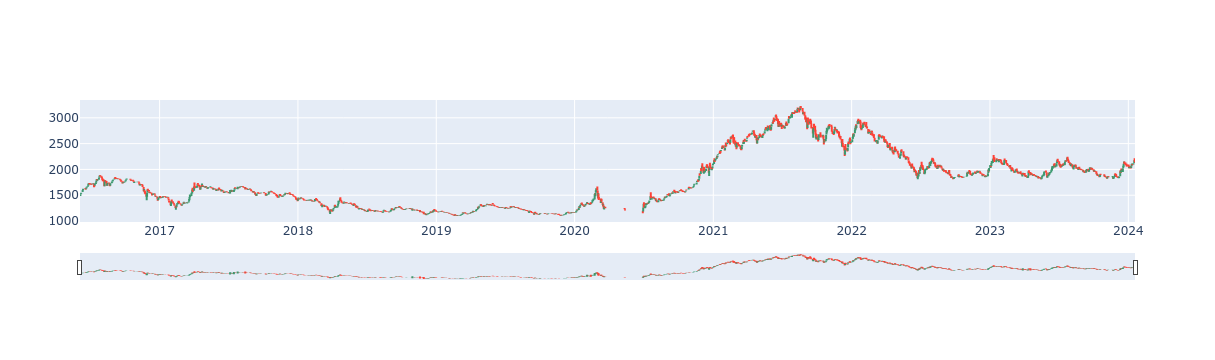

In [77]:
fig.add_trace(go.Candlestick(x=df['Timestamp'],
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'], name='OHLC'))

## RSI

In [78]:
from ta.momentum import RSIIndicator

df['RSI'] = RSIIndicator(df['Close'], window=14).rsi()

In [79]:
df[['Timestamp','RSI']].tail(10)

,Timestamp,RSI
1742,2024-01-04T14:59:59,58.683889
1743,2024-01-07T14:59:59,53.533121
1744,2024-01-08T14:59:59,58.920116
1745,2024-01-09T14:59:59,61.623033
1746,2024-01-10T14:59:59,62.835691
1747,2024-01-11T14:59:59,62.694211
1748,2024-01-14T14:59:59,66.742932
1749,2024-01-16T14:59:59,72.321946
1750,2024-01-17T14:59:59,69.533257
1751,2024-01-18T14:59:59,67.848832


## Stochastic RSI

In [80]:
from ta.momentum import stochrsi

In [81]:
df['StochRSI'] = stochrsi(df['Close'], window=14) * 100

In [82]:
df[['Timestamp','StochRSI']].tail(10)

,Timestamp,StochRSI
1742,2024-01-04T14:59:59,8.675140
1743,2024-01-07T14:59:59,0.000000
1744,2024-01-08T14:59:59,19.423393
1745,2024-01-09T14:59:59,29.169051
1746,2024-01-10T14:59:59,33.541423
1747,2024-01-11T14:59:59,33.031299
1748,2024-01-14T14:59:59,66.598390
1749,2024-01-16T14:59:59,100.000000
1750,2024-01-17T14:59:59,85.157724
1751,2024-01-18T14:59:59,76.192691
